### To run scRNA-seq analysis for head and neck cancer patients

Reference: https://www.nature.com/articles/s41467-023-36691-x#data-availability

data source: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE181919

https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/

CHETAH tumor reference and input data:
https://figshare.com/ndownloader/articles/6994007?private_link=aaf026376912366f81b6

https://nbisweden.github.io/excelerate-scRNAseq/session-celltypeid/celltypeid.html


In [4]:
# Set up
required.packages <- c("Seurat", "dplyr", "SingleR", "celldex", "SingleCellExperiment",
                       "glue", 'readxl', 'cowplot', 'ggplot2', 'viridis', 'tidyr', 
                       'harmony', 'SeuratData', 'rio', 'Matrix', 'celldex', 'SingleR') 

# if(!requireNamespace('remotes', quietly = TRUE)){
#   install.packages('remotes')}
#   
# remotes::install_github('satijalab/azimuth', ref = 'master')
# devtools::install_github('satijalab/seurat-data')
# devtools::install_github("navinlabcode/copykat")

new.packages <- required.packages[!(required.packages %in% installed.packages()[,"Package"])]

if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")


if(length(new.packages) > 0 ) BiocManager::install(new.packages)

sapply(required.packages, function(pkg){suppressPackageStartupMessages(require(pkg, character.only = TRUE))})

Seurat                dplyr              SingleR 
                TRUE                 TRUE                 TRUE 
             celldex SingleCellExperiment                 glue 
                TRUE                 TRUE                 TRUE 
              readxl              cowplot              ggplot2 
                TRUE                 TRUE                 TRUE 
             viridis                tidyr              harmony 
                TRUE                 TRUE                 TRUE 
          SeuratData                  rio               Matrix 
                TRUE                 TRUE                 TRUE 
             celldex              SingleR 
                TRUE                 TRUE

In [5]:
data.dir <- "/media/josh/samsung/data/single_cell_seq/Choi_head_neck_cancer"

if(!dir.exists(data.dir)){
    dir.create(data.dir, recursive = T)
}

date.str <- "05162024"

project = 'Choi_hnscc'

nFeature_lower <- 250
nFeature_upper <- 10000
nCount_lower <- 1000
nCount_upper <- 100000
pMT_lower <- 0
pMT_upper <- 25
pHB_lower <- 0
pHB_upper <- 5

In [6]:

URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/GSE181919_Barcode_metadata.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}


URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/GSE181919_UMI_counts.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}


URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/matrix/GSE181919_series_matrix.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}



In [7]:
meta <- read.table(glue('{data.dir}/GSE181919_Barcode_metadata.txt.gz'), sep = '\t', header = T, row.names=1)
row.names(meta) <- gsub('-', '.', row.names(meta))

In [8]:
head(meta, 2)

,patient.id,sample.id,Gender,Age,tissue.type,subsite,hpv,cell.type
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATGACGGA.1,P4,C04,F,58,CA,OC,HPV-,T.cells
AAAGATGAGCAGACTG.1,P4,C04,F,58,CA,OC,HPV-,T.cells


In [9]:
table(meta$cell.type)


   B_Plasma.cells   Dendritic.cells Endothelial.cells  Epithelial.cells 
             7437              1593              3437               993 
      Fibroblasts       Macrophages   Malignant.cells        Mast.cells 
            12336              4895              5113               270 
         Myocytes           T.cells 
              296             17869 

In [10]:
cnts <- read.table(glue('{data.dir}/GSE181919_UMI_counts.txt.gz'), sep = "\t", row.names=1, header=T)
cnts <- Matrix(as.matrix(cnts), sparse=T)


In [11]:
seu_obj <- CreateSeuratObject(counts = cnts, project = project, min.cells = 3, min.features = 200)

In [12]:
head(seu_obj@meta.data, 2)

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
AAACGGGCATGACGGA.1,Choi_hnscc,52412,5852
AAAGATGAGCAGACTG.1,Choi_hnscc,57290,6534


In [13]:
if( all(row.names(seu_obj@meta.data) == row.names(meta))){
    seu_obj <- AddMetaData(seu_obj, metadata = meta)


}



In [14]:
head(seu_obj@meta.data, 2)

,orig.ident,nCount_RNA,nFeature_RNA,patient.id,sample.id,Gender,Age,tissue.type,subsite,hpv,cell.type
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATGACGGA.1,Choi_hnscc,52412,5852,P4,C04,F,58,CA,OC,HPV-,T.cells
AAAGATGAGCAGACTG.1,Choi_hnscc,57290,6534,P4,C04,F,58,CA,OC,HPV-,T.cells


In [15]:

### calculate mitochondrial, hemoglobin and ribosomal gene counts
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^MT-", col.name = "pMT")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^HBA|^HBB", col.name = "pHB")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^RPS|^RPL", col.name = "pRP")

# Data Filtering 

seu_obj_filtered <- subset(seu_obj, subset = nFeature_RNA > nFeature_lower & nFeature_RNA < nFeature_upper & pMT < pMT_upper )

seu_obj_filtered

An object of class Seurat 
20000 features across 54233 samples within 1 assay 
Active assay: RNA (20000 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


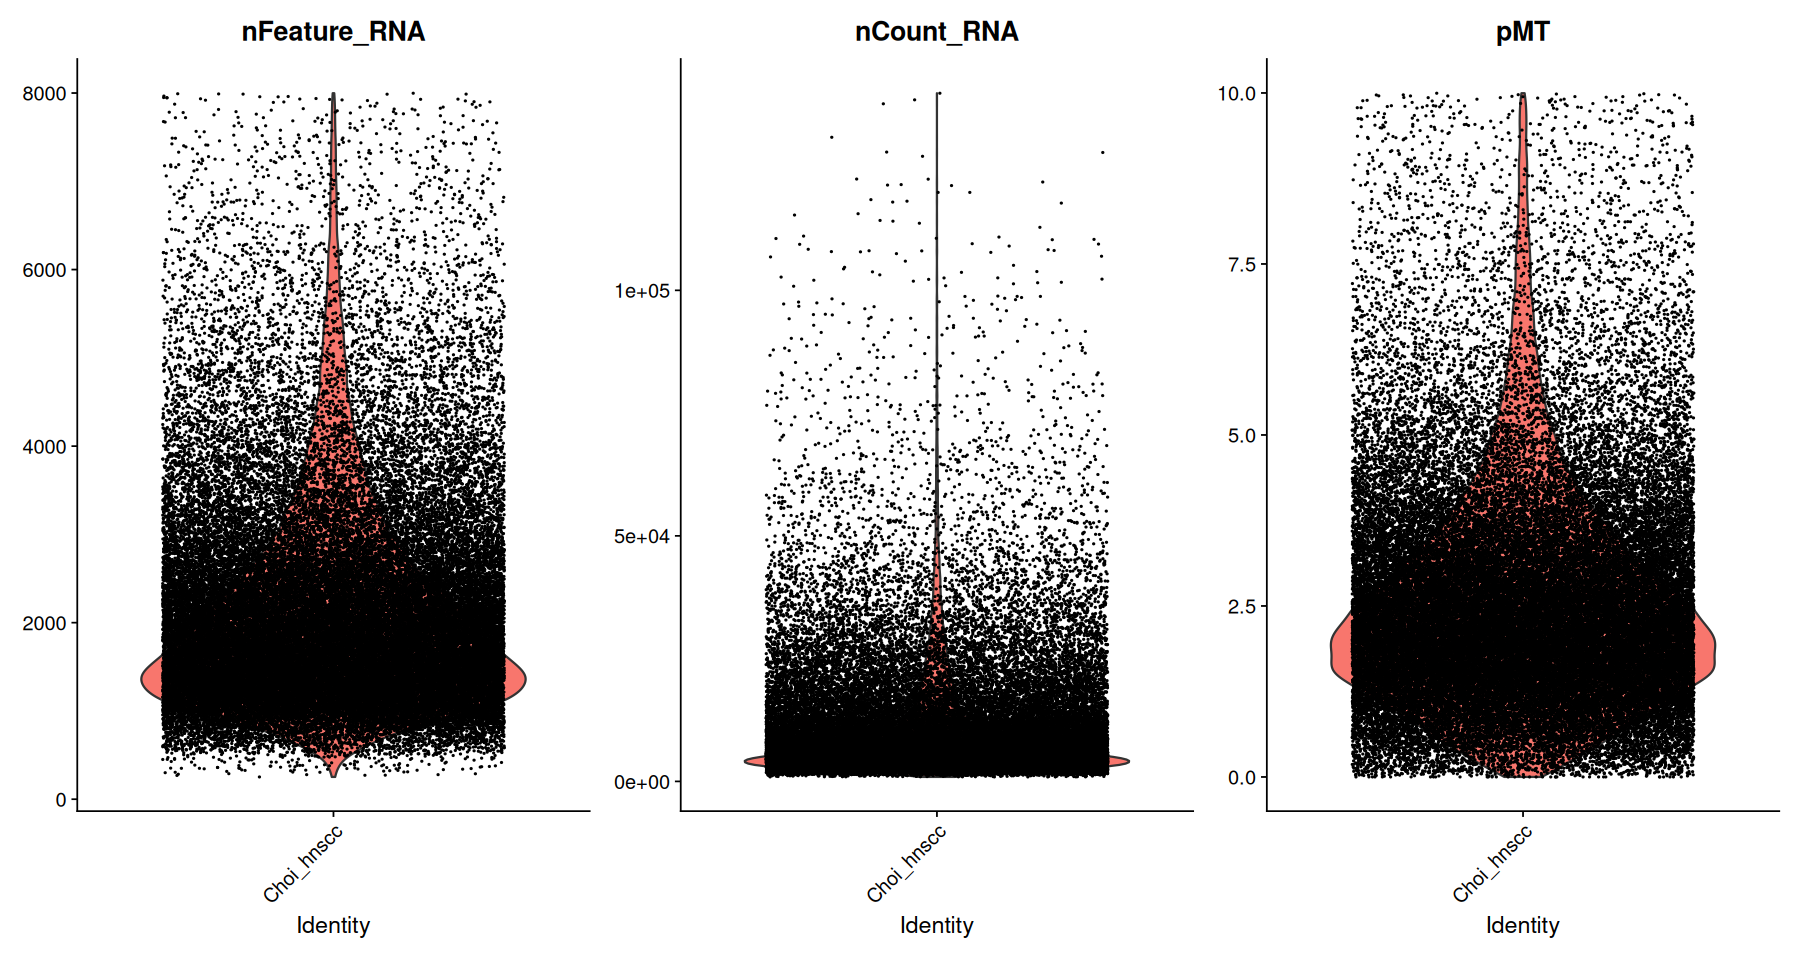

In [16]:
options(repr.plot.width = 15, repr.plot.height = 8)
VlnPlot(seu_obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "pMT"), ncol = 3)

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)
# Data normalization
gc()
seu_obj_filtered <- SCTransform(seu_obj_filtered, verbose = FALSE, vars.to.regress = c("nCount_RNA", "pMT"), conserve.memory = T)

gc()
# Dimensionality reduction
seu_obj_filtered <- RunPCA(seu_obj_filtered, verbose = FALSE)

seu_obj_filtered <- seu_obj_filtered %>% 
    RunHarmony("patient.id", plot_convergence = TRUE, assay.use = "SCT", verbose = FALSE)

# seu_obj_filtered <- RunUMAP(seu_obj_filtered, reduction = "harmony")
seu_obj_filtered <- seu_obj_filtered %>% 
    RunUMAP(reduction = "harmony", dims = 1:20, verbose = FALSE) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:20, verbose = FALSE)

for (i in c(0.2, 0.3, 0.4, 0.5, 1, 2)) {
  seu_obj_filtered <- FindClusters(seu_obj_filtered, resolution = i, verbose = FALSE)
  print(DimPlot(seu_obj_filtered, reduction = "umap") + labs(title = paste0("resolution: ", i)))
}



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11199833,598.2,16359350,873.7,16359350,873.7
Vcells,553437764,4222.4,1555150044,11864.9,2429919278,18538.9


`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.




In [ ]:
options(repr.plot.width = 9, repr.plot.height = 8)

n_colors <- length(unique(seu_obj_filtered@meta.data$cell.type))
colors <- DiscretePalette(n_colors, palette = "glasbey")
DimPlot(seu_obj_filtered, group.by = "cell.type", label = FALSE,  cols = colors)

In [ ]:
saveRDS(seu_obj_filtered, glue('{data.dir}/Choi_hnscc.rds'))
# seu_obj_filtered <- readRDS(glue('{data.dir}/Choi_hnscc.rds'))

In [18]:
unique(seu_obj_filtered$tissue.type)

[1] "CA" "LN" "NL" "LP"

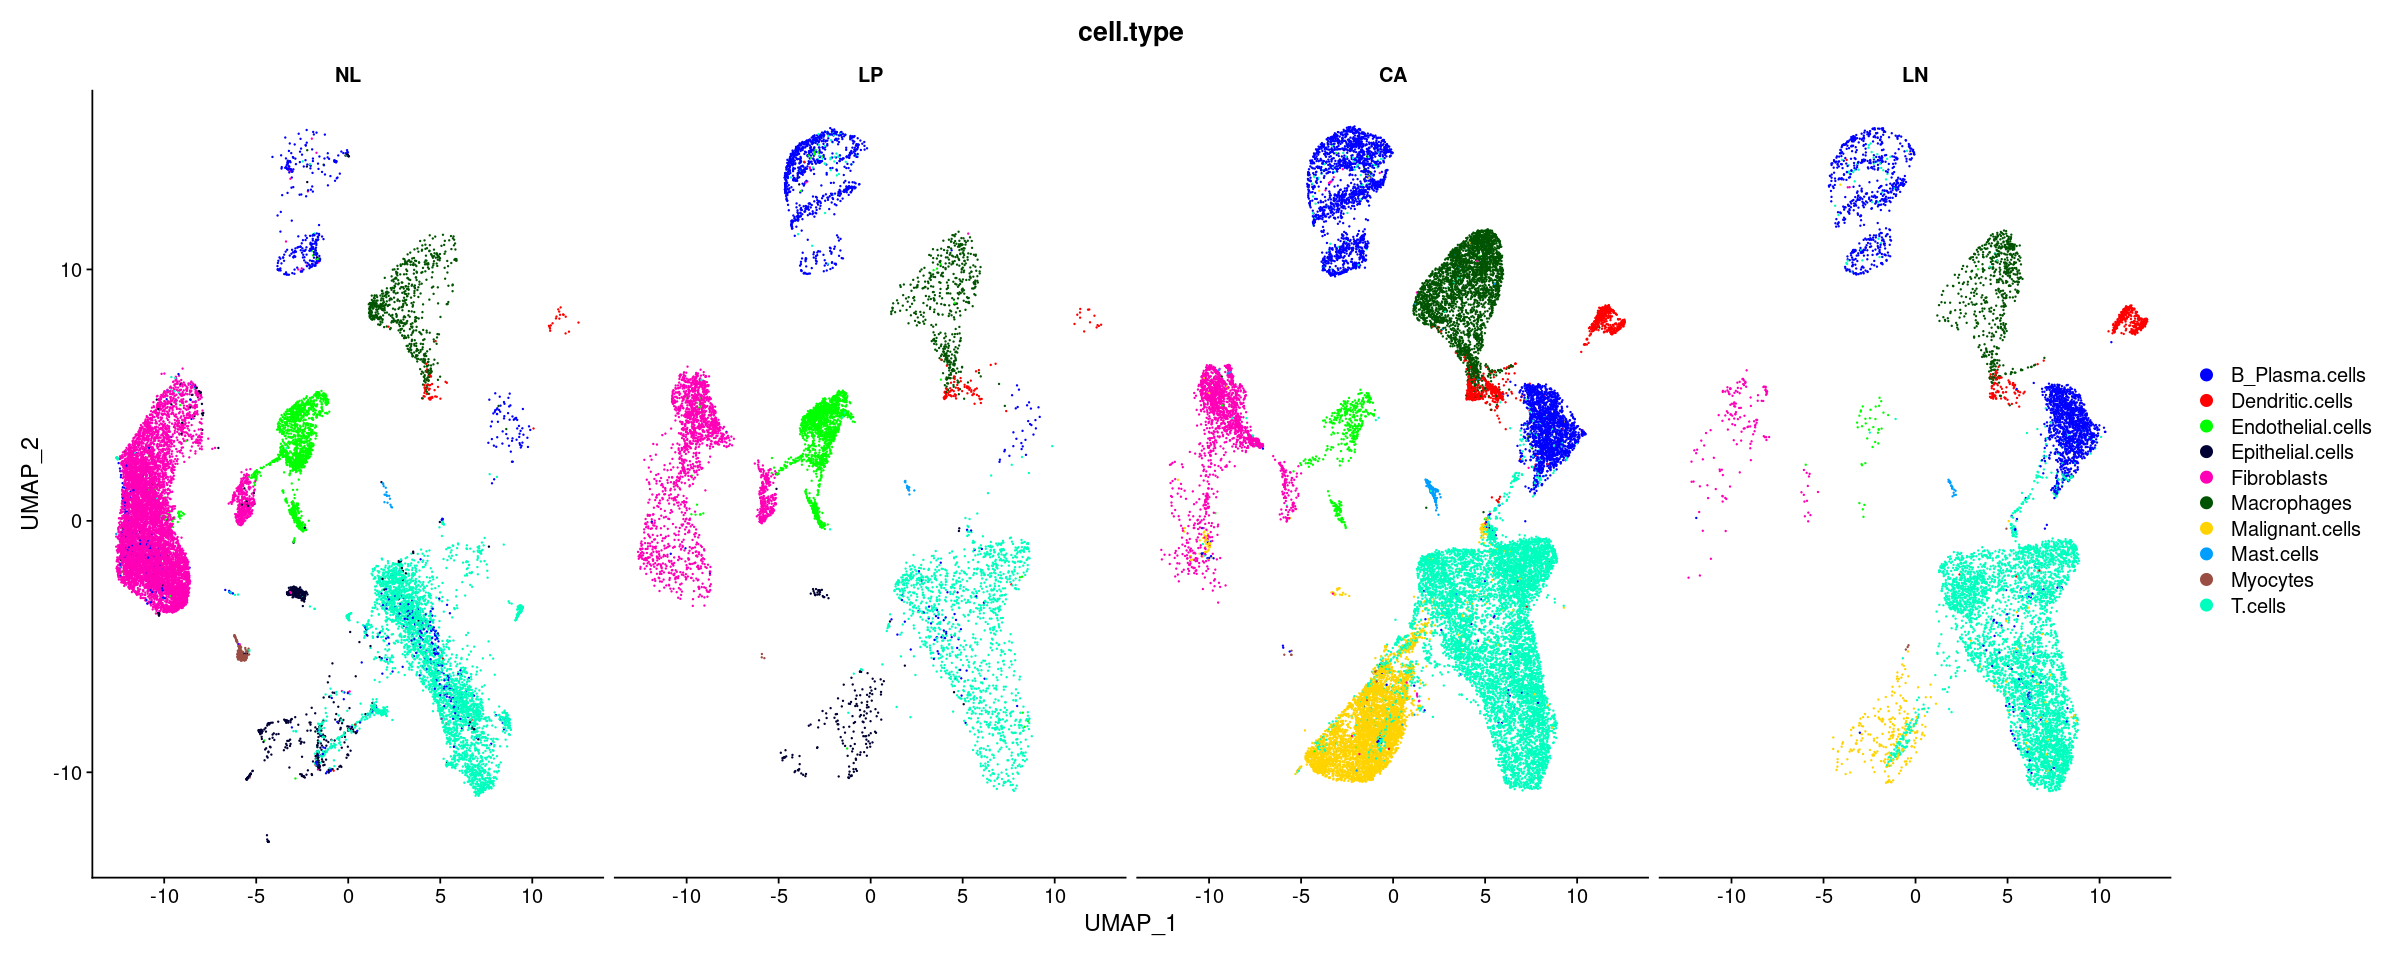

In [19]:
options(repr.plot.width = 20, repr.plot.height = 8)
# tissue.type
# normal tissue (NL, n = 9), leukoplakia (LP, n = 4), primary cancer (CA, n = 20), and metastatic tumors in lymph nodes (LN, n = 4)

seu_obj_filtered$tissue.type <- factor(seu_obj_filtered$tissue.type, levels = c('NL', 'LP', 'CA', 'LN'))
n_colors <- length(unique(seu_obj_filtered@meta.data$cell.type))
colors <- DiscretePalette(n_colors, palette = "glasbey")
DimPlot(seu_obj_filtered, group.by = "cell.type", label = FALSE,  cols = colors, split.by = 'tissue.type')

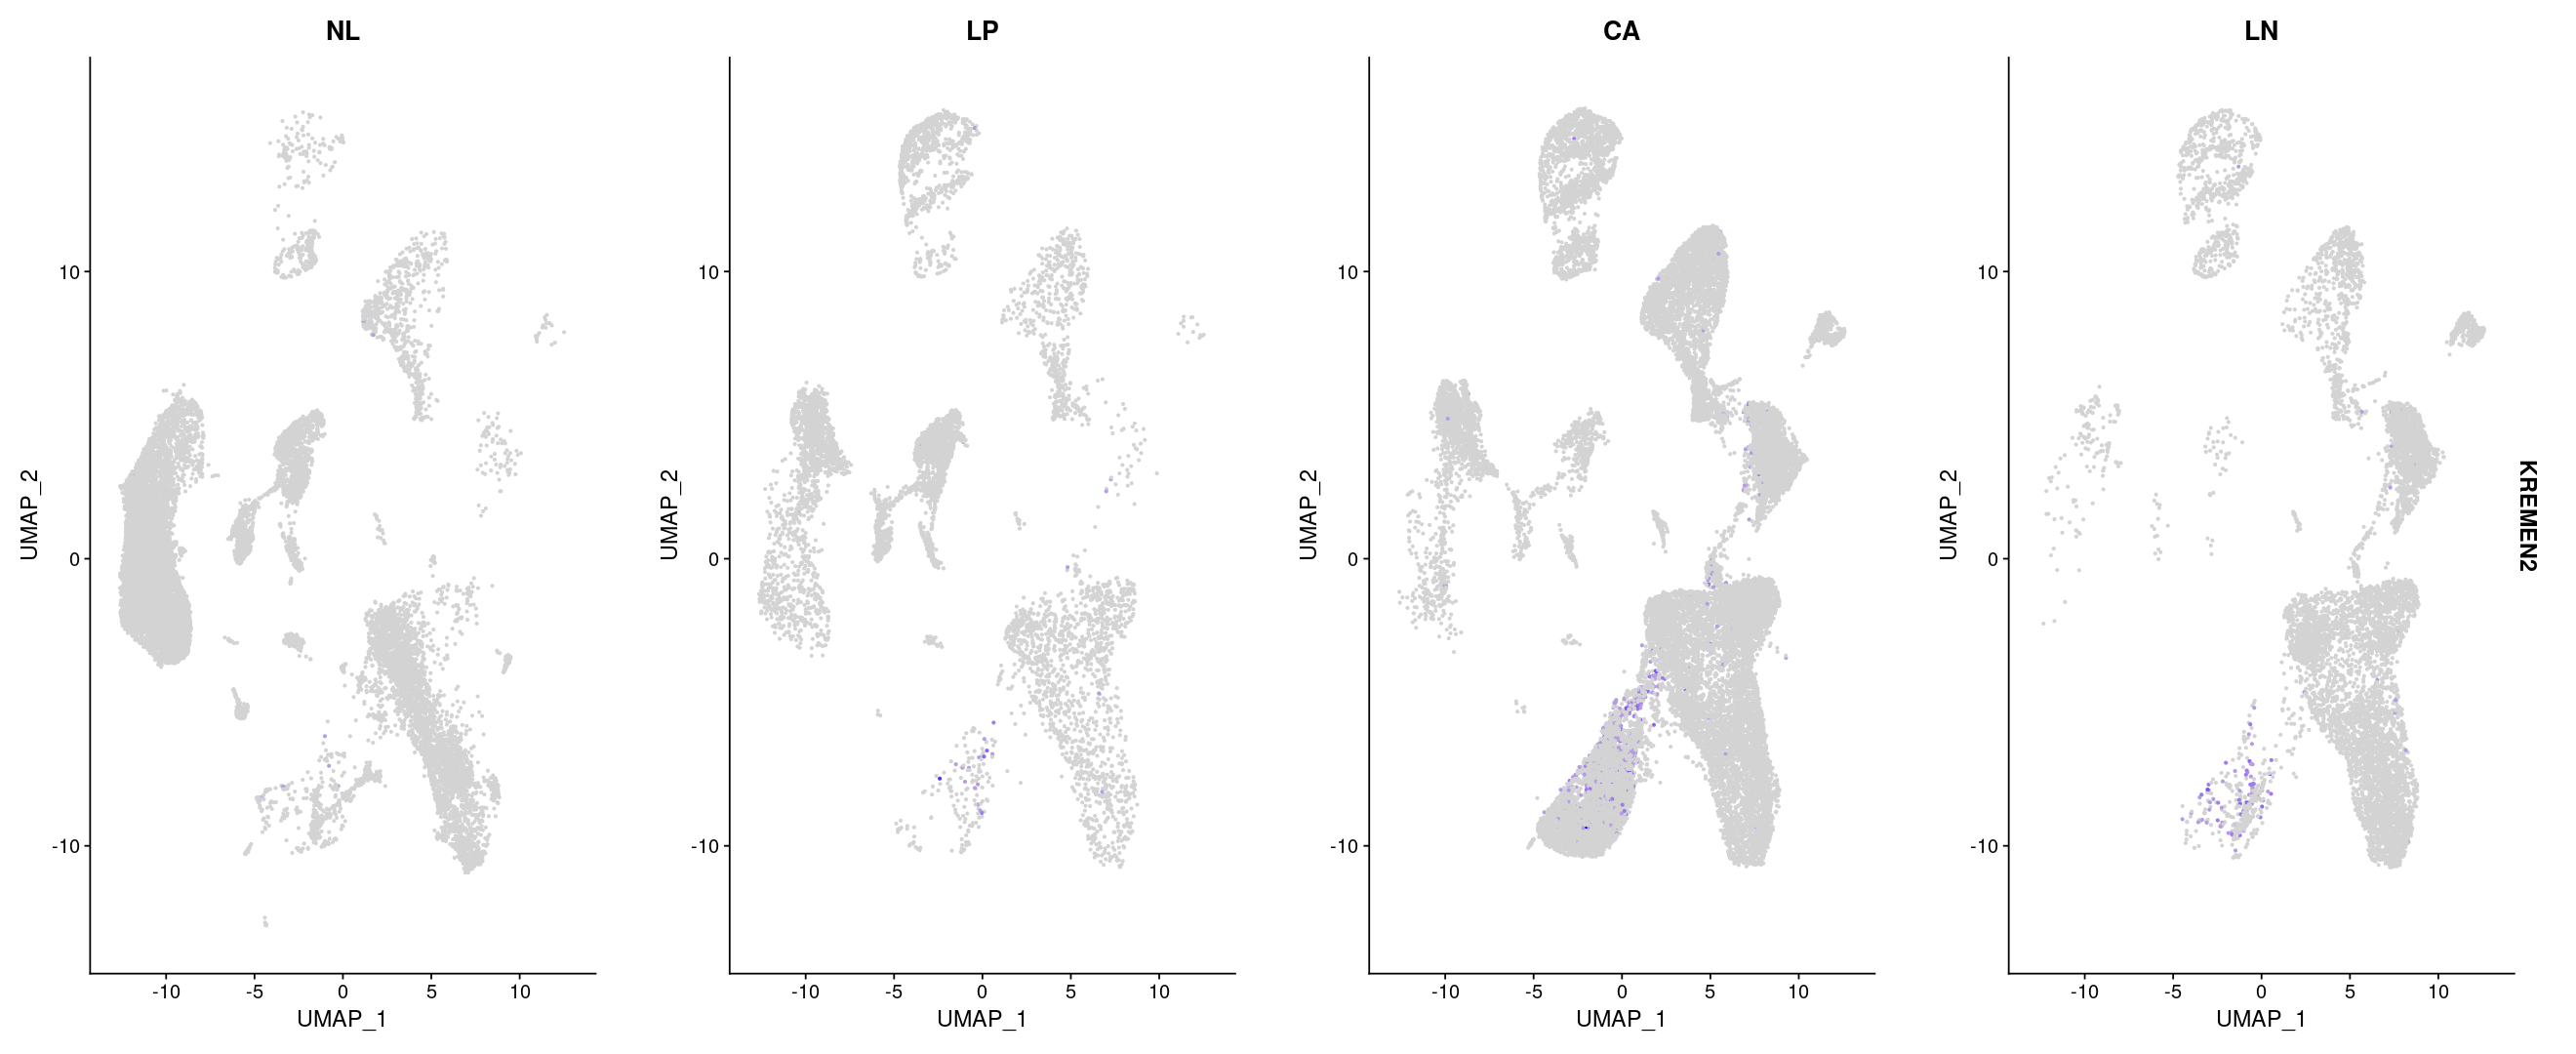

In [20]:
options(repr.plot.width = 22, repr.plot.height = 9)

gene <- 'KREMEN2'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'tissue.type', pt.size = 0.5)
  


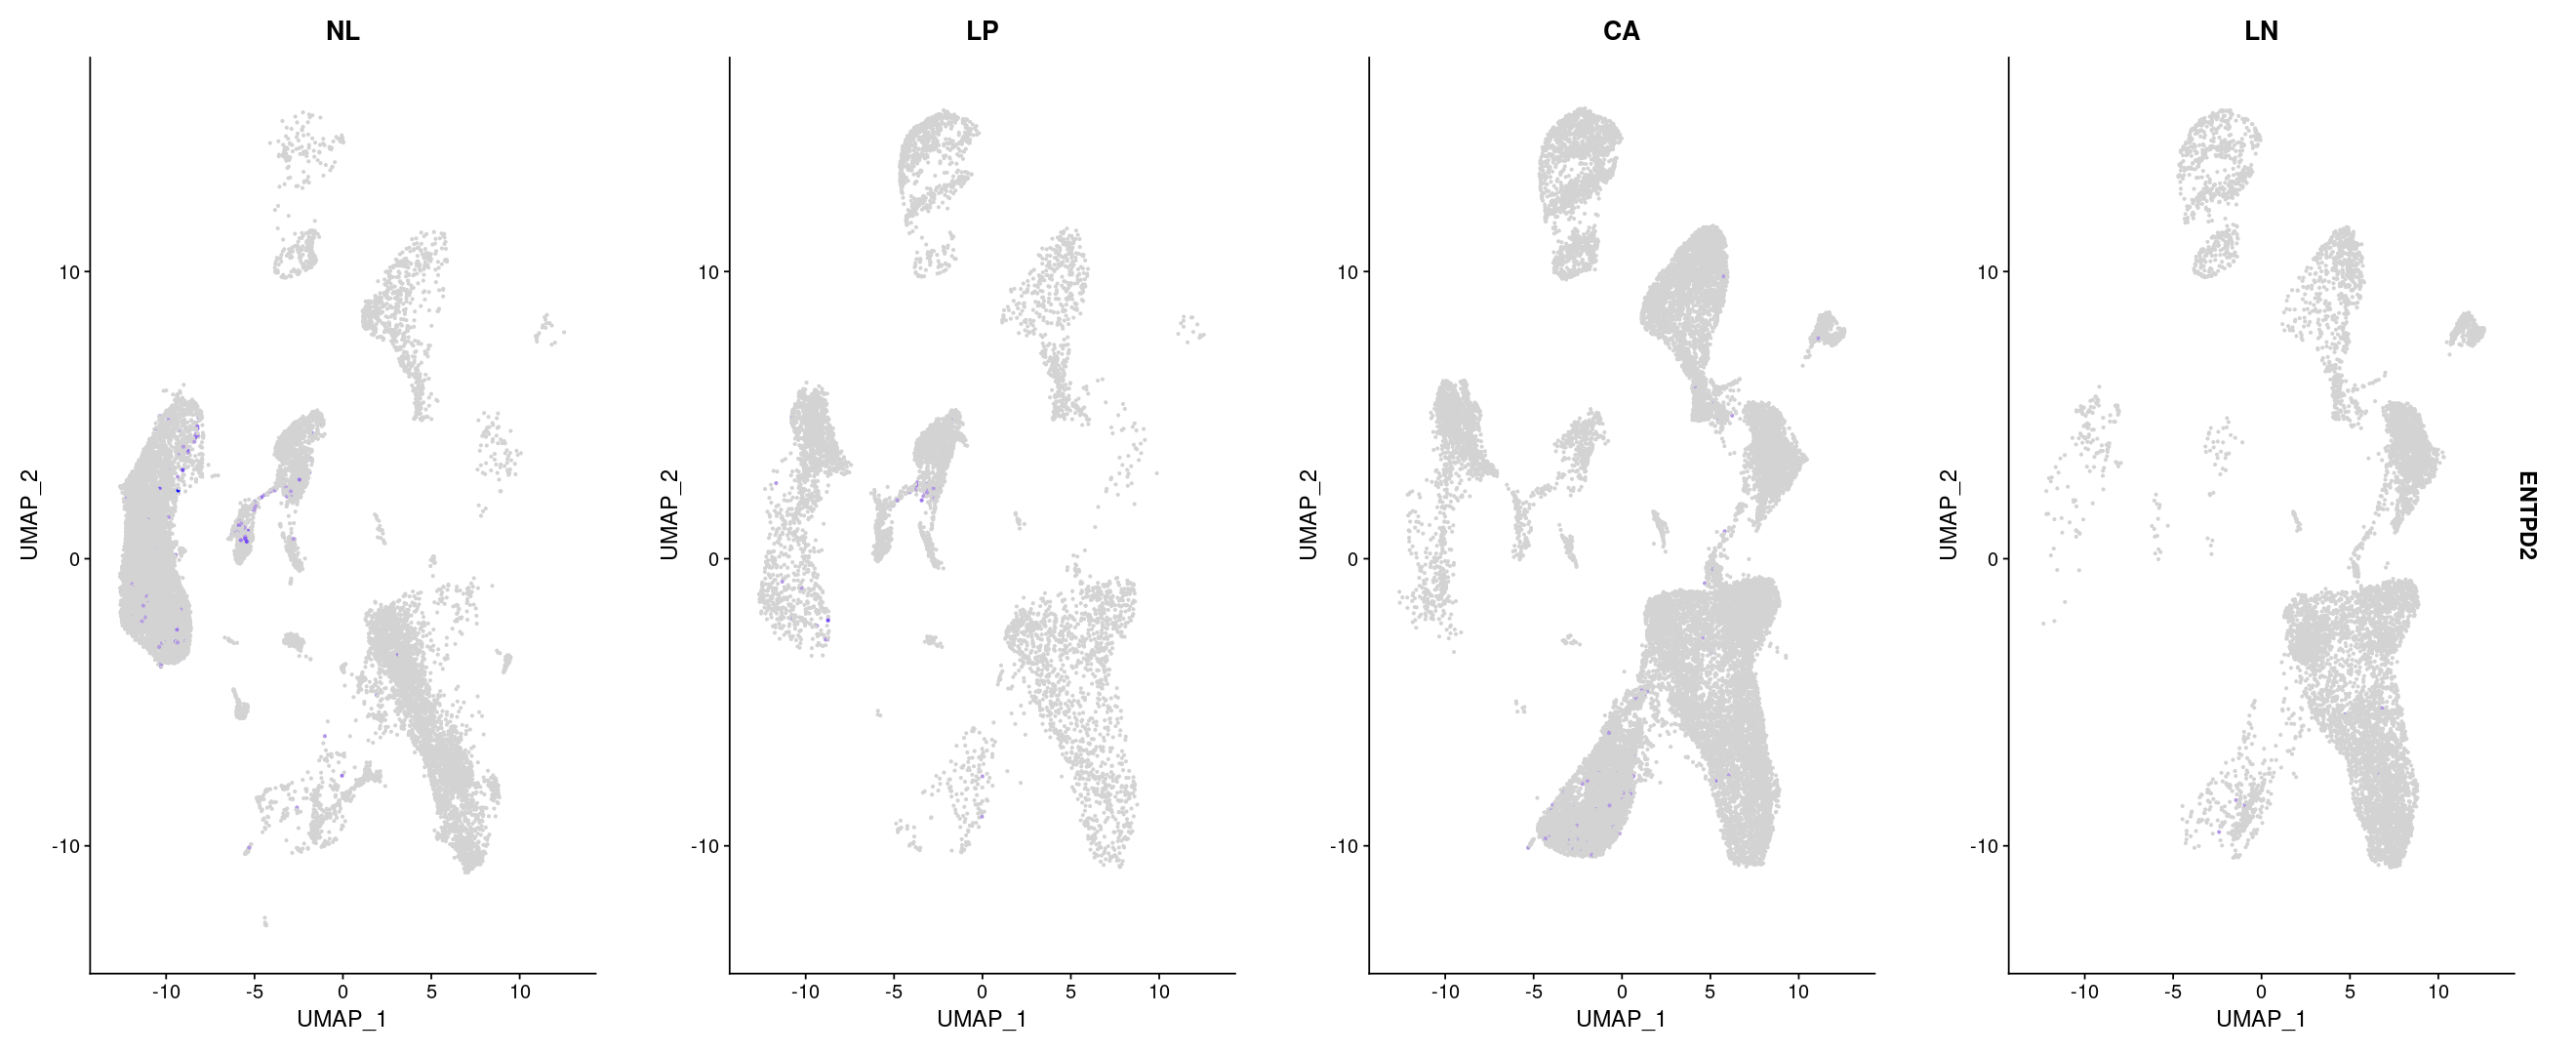

In [21]:
options(repr.plot.width = 22, repr.plot.height = 9)

gene <- 'ENTPD2'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'tissue.type', pt.size = 0.5)